In [ ]:
"""
Version 2 - Encoder-Decoder with Attention

Key improvements:
- Encoder-decoder architecture
- Self-attention and cross-attention
- Teacher forcing
- Padding masking
- Autoregressive decoding

This is the current production version of the model.
"""

In [ ]:
import tensorflow as tf
import numpy as np
import pathlib
import matplotlib.pyplot as plt
import os
import pandas as pd
from pathlib import Path
import json
import re
import random
from tensorflow.keras.layers import RandomRotation, RandomZoom



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
imgdir_path = pathlib.Path('/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/Dataset')
csv_path = '/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/caption_data.csv'
json_path = '/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/char_dict.json'

In [ ]:
file_list = sorted([str(path) for path in imgdir_path.glob('*.bmp')])

print("Número de imágenes:", len(file_list))
print(file_list[:5])

Número de imágenes: 12167
['/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/Dataset/101_Fabricio.bmp', '/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/Dataset/101_Frank.bmp', '/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/Dataset/101_Nina.bmp', '/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/Dataset/101_alfonso.bmp', '/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/Dataset/101_carlos.bmp']


Image Size: (97, 412, 1)
Image Size: (125, 577, 1)
Image Size: (113, 411, 1)
Image Size: (109, 409, 1)
Image Size: (93, 440, 1)
Image Size: (114, 384, 1)


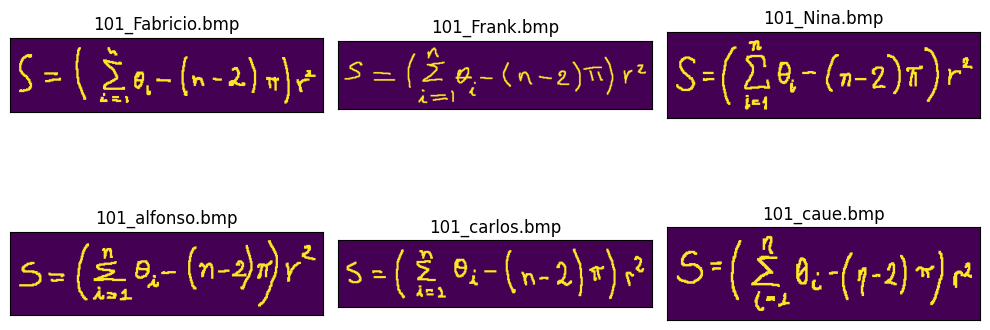

In [ ]:
fig = plt.figure(figsize=(10,5))

for i, file in enumerate(file_list[:6]):
    img_raw = tf.io.read_file(file)
    img = tf.image.decode_image(img_raw)

    print('Image Size:', img.shape)

    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=12)

plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv(csv_path)

df.rename(columns={
    'Column1': 'image_name',
    'Column2': 'caption'
}, inplace=True)

df.head()

,image_name,caption
0,18_em_0,x _ { k } x x _ { k } + y _ { k } y x _ { k }
1,18_em_10,2 6
2,18_em_11,q _ { t } = 2 q
3,18_em_12,\frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } }
4,18_em_13,4 ^ { 2 } + 4 ^ { 2 } + \frac { 4 } { 4 }


In [ ]:
df["path"] = df["image_name"].apply(
    lambda x: str(imgdir_path / (x + ".bmp"))
)

df.head()

,image_name,caption,path
0,18_em_0,x _ { k } x x _ { k } + y _ { k } y x _ { k },/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Arch...
1,18_em_10,2 6,/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Arch...
2,18_em_11,q _ { t } = 2 q,/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Arch...
3,18_em_12,\frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } },/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Arch...
4,18_em_13,4 ^ { 2 } + 4 ^ { 2 } + \frac { 4 } { 4 },/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Arch...


In [ ]:
file_list = df["path"].tolist()
labels = df["caption"].tolist()

In [ ]:
with open(json_path, "r", encoding="utf8") as f:
    rules = json.load(f)

# extraer comandos LaTeX
latex_commands = set()

for expr in df["caption"]:
    cmds = re.findall(r'\\[a-zA-Z]+', str(expr))
    latex_commands.update(cmds)

# comparar
json_commands = set(rules.keys())

faltantes = latex_commands - json_commands

print("Comandos en dataset:", len(latex_commands))
print("Comandos en JSON:", len(json_commands))
print("Faltantes:", faltantes)

Comandos en dataset: 35
Comandos en JSON: 76
Faltantes: {'\\rightarrow', '\\leq', '\\ldots', '\\theta', '\\prime', '\\sum', '\\pm', '\\cos', '\\in', '\\int', '\\gamma', '\\sin', '\\pi', '\\phi', '\\cdot', '\\limits', '\\geq', '\\lambda', '\\alpha', '\\sqrt', '\\infty', '\\neq', '\\div', '\\tan', '\\forall', '\\frac', '\\cdots', '\\mu', '\\beta', '\\times', '\\lim', '\\exists', '\\sigma', '\\log', '\\Delta'}


In [ ]:
all_tokens = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"] + sorted(json_commands | faltantes)

token2id = {token: i for i, token in enumerate(all_tokens)}
id2token = {i: token for token, i in token2id.items()}

with open("vocabulario.json", "w", encoding="utf-8") as f:
    json.dump(token2id, f, ensure_ascii=False, indent=4)

In [ ]:
with open("vocabulario.json", "r") as f:
    vocab = json.load(f)

In [ ]:
def tokenize_latex(expr):
    return expr.split()

def encode_latex(expr, vocab):
    tokens = tokenize_latex(expr)

    encoded = [vocab["<BOS>"]]

    for t in tokens:
        encoded.append(vocab.get(t, vocab["<UNK>"]))

    encoded.append(vocab["<EOS>"])

    return encoded

labels_encoded = [encode_latex(eq, vocab) for eq in labels]

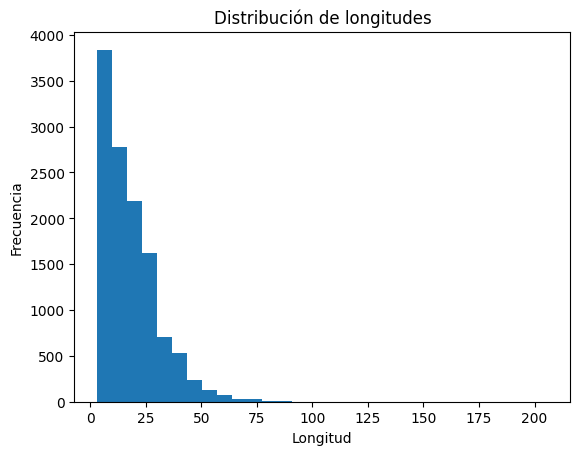

Min: 3
Max: 206
Promedio: 17.872441850908196
P95: 41.0


In [ ]:
lengths = [len(seq) for seq in labels_encoded]

plt.hist(lengths, bins=30)
plt.title("Distribución de longitudes")
plt.xlabel("Longitud")
plt.ylabel("Frecuencia")
plt.show()

print("Min:", np.min(lengths))
print("Max:", np.max(lengths))
print("Promedio:", np.mean(lengths))
print("P95:", np.percentile(lengths, 95))

In [ ]:
for i in range(15):
    print("Original:", labels[i])
    print("Tokens:", tokenize_latex(labels[i]))
    print("Encoded:", labels_encoded[i])
    print("-"*40)

Original: x _ { k } x x _ { k } + y _ { k } y x _ { k }
Tokens: ['x', '_', '{', 'k', '}', 'x', 'x', '_', '{', 'k', '}', '+', 'y', '_', '{', 'k', '}', 'y', 'x', '_', '{', 'k', '}']
Encoded: [1, 109, 85, 112, 96, 114, 109, 109, 85, 112, 96, 114, 9, 110, 85, 112, 96, 114, 110, 109, 85, 112, 96, 114, 2]
----------------------------------------
Original: 2 6
Tokens: ['2', '6']
Encoded: [1, 16, 20, 2]
----------------------------------------
Original: q _ { t } = 2 q
Tokens: ['q', '_', '{', 't', '}', '=', '2', 'q']
Encoded: [1, 102, 85, 112, 105, 114, 25, 16, 102, 2]
----------------------------------------
Original: \frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } }
Tokens: ['\\frac', '{', 'p', 'e', '^', '{', 't', '}', '}', '{', '1', '-', '(', '1', '-', 'p', ')', 'e', '^', '{', 't', '}', '}']
Encoded: [1, 57, 112, 101, 90, 84, 112, 105, 114, 114, 112, 15, 11, 7, 15, 11, 101, 8, 90, 84, 112, 105, 114, 114, 2]
----------------------------------------
Original: 4 ^ { 2 } + 4 ^ { 2 } + \frac { 4

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50  # puedes ajustar con P95

labels_padded = pad_sequences(
    labels_encoded,
    maxlen=max_len,
    padding="post",
    value=vocab["<PAD>"]
)

for i in range(5):
    print("Padded:", labels_padded[i])

Padded: [  1 109  85 112  96 114 109 109  85 112  96 114   9 110  85 112  96 114
 110 109  85 112  96 114   2   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded: [ 1 16 20  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]
Padded: [  1 102  85 112 105 114  25  16 102   2   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded: [  1  57 112 101  90  84 112 105 114 114 112  15  11   7  15  11 101   8
  90  84 112 105 114 114   2   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded: [  1  18  84 112  16 114   9  18  84 112  16 114   9  57 112  18 114 112
  18 114   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0

In [ ]:
img_width = 384
img_height = 128

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    # Leer como RGB
    image = tf.image.decode_bmp(image, channels=3)
    # Convertir a escala de grises
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.resize(image, [img_height, img_width])
    image = image / 255.0
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.int32)
    if len(image.shape) == 2:
        image = tf.expand_dims(image, axis=-1)

    return image, label

In [ ]:
ds = tf.data.Dataset.from_tensor_slices((file_list, labels_padded))
ds = ds.shuffle(buffer_size=6000)

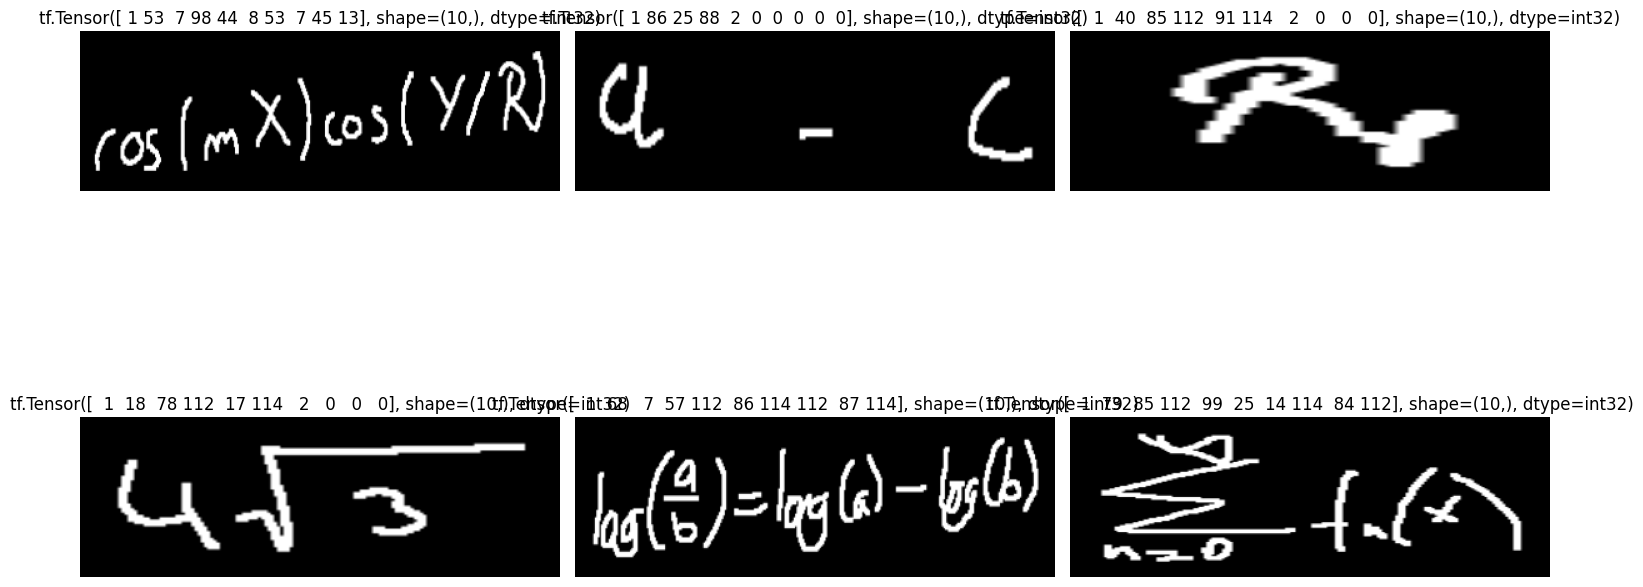

In [ ]:
# Tomar 6 índices aleatorios
indices = random.sample(range(len(file_list)), 6)

fig = plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):
    img, label = load_and_preprocess(file_list[idx], labels_padded[idx])

    img_np = img.numpy()

    if img_np.shape[-1] == 1:
        img_np = img_np[:, :, 0]

    ax = fig.add_subplot(2, 3, i+1)
    ax.imshow(img_np, cmap="gray")
    ax.set_title(str(label[:10]))  # primeros tokens
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Mezclar dataset
BUFFER_SIZE = len(file_list)
#ds = ds.shuffle(buffer_size=BUFFER_SIZE, reshuffle_each_iteration=False)
ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Tomar 6000 muestras
ds_small = ds.take(10000)

# Tamaños
total_size = 10000
train_size = int(0.7 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

# División
ds_train = ds_small.take(train_size)
ds_temp = ds_small.skip(train_size)

ds_val = ds_temp.take(val_size)
ds_test = ds_temp.skip(val_size)

# Batching
BATCH_SIZE = 16

ds_train = ds_train.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
def prepare_teacher_forcing(images, labels):
    decoder_in = labels[:, :-1]                              # (B, 49) — empieza en BOS
    target     = labels[:, 1:]                               # (B, 49) — termina en EOS
    mask       = tf.cast(tf.not_equal(target, 0), tf.float32) # ignora PAD en la loss
    return (images, decoder_in), target, mask

ds_train = ds_train.map(prepare_teacher_forcing)
ds_val   = ds_val.map(prepare_teacher_forcing)
ds_test  = ds_test.map(prepare_teacher_forcing)

In [ ]:
# -----------------------------
# Residual Block
# -----------------------------
def residual_block(x, filters):
    shortcut = x

    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(
            filters, (1,1), padding='same'
        )(shortcut)

    x = tf.keras.layers.Conv2D(filters, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x)

    x = tf.keras.layers.Conv2D(filters, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('gelu')(x)

    return x


# -----------------------------
# Entrada
# -----------------------------
image_input = tf.keras.Input(shape=(128, 384, 1), name="image_input")


# -----------------------------
# CNN
# -----------------------------

x = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='gelu')(image_input)

x = residual_block(x, 32)
x = tf.keras.layers.MaxPool2D((2,2))(x)

x = residual_block(x, 64)
x = tf.keras.layers.MaxPool2D((2,2))(x)

x = residual_block(x, 128)
x = tf.keras.layers.MaxPool2D((2,1))(x)

x = residual_block(x, 256)
x = tf.keras.layers.MaxPool2D((2,1))(x)

# -----------------------------
# CNN → LSTM
# -----------------------------

x = tf.keras.layers.Permute((2, 1, 3))(x)
x = tf.keras.layers.Reshape((96, 8 * 256))(x)
x = tf.keras.layers.Dense(256, activation='gelu')(x)

encoder_out = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(128, return_sequences=True)
)(x)
encoder_out = tf.keras.layers.LayerNormalization()(encoder_out)

vocab_size = len(vocab)   # ← agregar aquí

decoder_input = tf.keras.Input(shape=(None,), name="decoder_input")

emb = tf.keras.layers.Embedding(vocab_size, 256)(decoder_input)

self_attn = tf.keras.layers.MultiHeadAttention(
    num_heads=4, key_dim=64, dropout=0.1, name="self_attention"
)
self_out = self_attn(
    query=emb, key=emb, value=emb,
    use_causal_mask=True   # ← bloquea posiciones futuras
)
self_out = tf.keras.layers.Add()([emb, self_out])           # residual
self_out = tf.keras.layers.LayerNormalization()(self_out)

cross_attn = tf.keras.layers.MultiHeadAttention(
    num_heads=4, key_dim=64, dropout=0.1, name="cross_attention"
)
cross_out = cross_attn(
    query=self_out, key=encoder_out, value=encoder_out
)
cross_out = tf.keras.layers.Add()([self_out, cross_out])     # residual
cross_out = tf.keras.layers.LayerNormalization()(cross_out)  # (B, 49, 256)

# ── LSTM: generación secuencial con contexto visual ─────────────────────────
x = tf.keras.layers.LSTM(512, return_sequences=True, dropout=0.3)(cross_out)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(vocab_size, activation='softmax')(x)

model = tf.keras.Model(
    inputs=[image_input, decoder_input],
    outputs=outputs
)

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    weighted_metrics=[]   # evita que Keras duplique la métrica con el mask
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5",
    monitor="val_loss",
    save_best_only=True, mode="min", verbose=1
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 384,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 384,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 384,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 384,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 384,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 384,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 384,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 384,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 384,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 192,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 192,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 192,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 192,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 192,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 192,   │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 192,   │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192,   │          0 │ batch_normalizat

 Total params: 4,338,227 (16.55 MB)

 Trainable params: 4,336,307 (16.54 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [26]:
EPOCHS = 40

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.1195 - loss: 0.9320
Epoch 1: val_loss improved from None to 0.86870, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 1: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 371s 790ms/step - accuracy: 0.1458 - loss: 0.8000 - val_accuracy: 0.1440 - val_loss: 0.8687
Epoch 2/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.1706 - loss: 0.6639
Epoch 2: val_loss improved from 0.86870 to 0.58002, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 2: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 160s 365ms/step - accuracy: 0.1753 - loss: 0.6352 - val_accuracy: 0.2018 - val_loss: 0.5800
Epoch 3/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.1809 - loss: 0.5947
Epoch 3: val_loss improved from 0.58002 to 0.51115, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 3: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 161s 367ms/step - accuracy: 0.1879 - loss: 0.5753 - val_accuracy: 0.2266 - val_loss: 0.5111
Epoch 4/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.1929 - loss: 0.5575
Epoch 4: val_loss improved from 0.51115 to 0.45791, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 4: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 201s 366ms/step - accuracy: 0.1983 - loss: 0.5304 - val_accuracy: 0.2383 - val_loss: 0.4579
Epoch 5/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.2048 - loss: 0.5222
Epoch 5: val_loss improved from 0.45791 to 0.41640, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5


...


Epoch 28: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 210s 383ms/step - accuracy: 0.3082 - loss: 0.1019 - val_accuracy: 0.3248 - val_loss: 0.0501
Epoch 29/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.3070 - loss: 0.1006
Epoch 29: val_loss improved from 0.05014 to 0.04575, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 29: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 160s 366ms/step - accuracy: 0.3050 - loss: 0.0999 - val_accuracy: 0.3298 - val_loss: 0.0457
Epoch 30/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3066 - loss: 0.0987
Epoch 30: val_loss did not improve from 0.04575
438/438 ━━━━━━━━━━━━━━━━━━━━ 199s 359ms/step - accuracy: 0.3053 - loss: 0.0918 - val_accuracy: 0.3343 - val_loss: 0.0469
Epoch 31/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.3063 - loss: 0.0883
Epoch 31: val_loss did not improve from 0.04575
438/438 ━━━━━━━━━━━━━━━━━━━━ 202s 359ms/step - accuracy: 0.3106 - loss: 0.0875 - val_accuracy: 0.3320 - val_loss: 0.0461
Epoch 32/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3043 - loss: 0.0877
Epoch 32: val_loss improved from 0.04575 to 0.03782, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 32: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 168s 383ms/step - accuracy: 0.3074 - loss: 0.0844 - val_accuracy: 0.3299 - val_loss: 0.0378
Epoch 33/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3139 - loss: 0.0830
Epoch 33: val_loss did not improve from 0.03782
438/438 ━━━━━━━━━━━━━━━━━━━━ 158s 359ms/step - accuracy: 0.3123 - loss: 0.0794 - val_accuracy: 0.3223 - val_loss: 0.0384
Epoch 34/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3148 - loss: 0.0786
Epoch 34: val_loss did not improve from 0.03782
438/438 ━━━━━━━━━━━━━━━━━━━━ 157s 358ms/step - accuracy: 0.3155 - loss: 0.0763 - val_accuracy: 0.3395 - val_loss: 0.0384
Epoch 35/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3071 - loss: 0.0768
Epoch 35: val_loss improved from 0.03782 to 0.03106, saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5



Epoch 35: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 159s 364ms/step - accuracy: 0.3082 - loss: 0.0733 - val_accuracy: 0.3331 - val_loss: 0.0311
Epoch 36/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3068 - loss: 0.0708
Epoch 36: val_loss did not improve from 0.03106
438/438 ━━━━━━━━━━━━━━━━━━━━ 158s 360ms/step - accuracy: 0.3126 - loss: 0.0689 - val_accuracy: 0.3409 - val_loss: 0.0350
Epoch 37/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3165 - loss: 0.0698
Epoch 37: val_loss did not improve from 0.03106
438/438 ━━━━━━━━━━━━━━━━━━━━ 157s 358ms/step - accuracy: 0.3139 - loss: 0.0666 - val_accuracy: 0.3396 - val_loss: 0.0334
Epoch 38/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.3142 - loss: 0.0673
Epoch 38: val_loss did not improve from 0.03106
438/438 ━━━━━━━━━━━━━━━━━━━━ 157s 359ms/step - accuracy: 0.3167 - loss: 0.0654 - val_accuracy: 0.3404 - val_loss: 0.0331
Ep


Epoch 39: finished saving model to /content/drive/MyDrive/IA_SAMSUNG/Modelo_/Archivos/mejor_modelo.h5
438/438 ━━━━━━━━━━━━━━━━━━━━ 160s 366ms/step - accuracy: 0.3167 - loss: 0.0635 - val_accuracy: 0.3308 - val_loss: 0.0276
Epoch 40/40
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.3144 - loss: 0.0621
Epoch 40: val_loss did not improve from 0.02761
438/438 ━━━━━━━━━━━━━━━━━━━━ 159s 362ms/step - accuracy: 0.3142 - loss: 0.0601 - val_accuracy: 0.3396 - val_loss: 0.0289


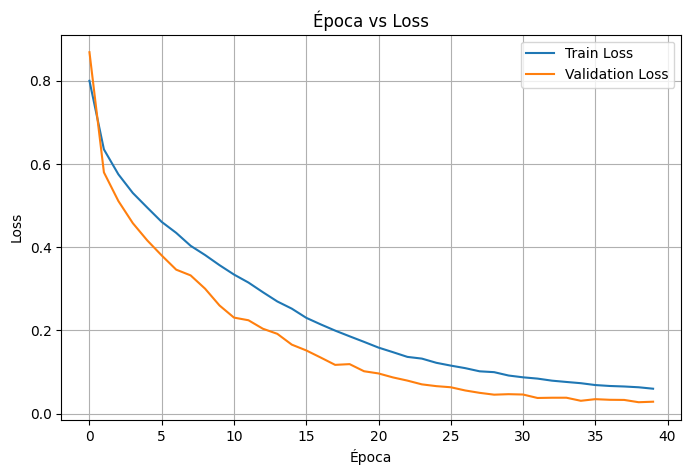

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Época vs Loss')
plt.legend()
plt.grid()

plt.show()

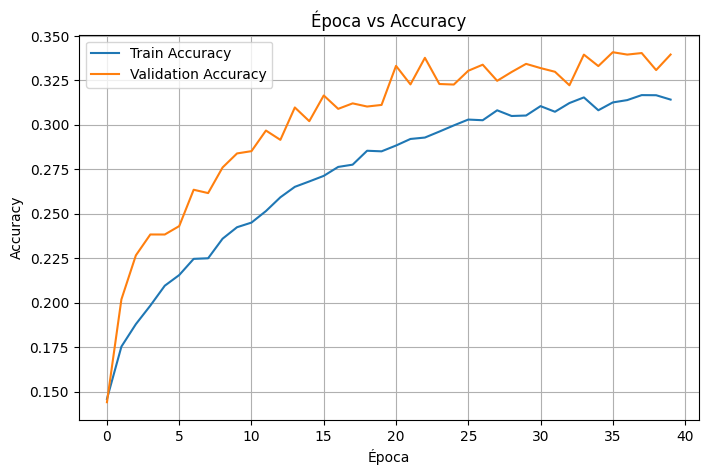

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Época vs Accuracy')
plt.legend()
plt.grid()

plt.show()

In [29]:
def greedy_decode(model, image, vocab, id2token, max_len=49):
    bos_id = vocab["<BOS>"]
    eos_id = vocab["<EOS>"]

    image_batch = tf.expand_dims(image, axis=0)  # (1, H, W, 1)
    decoder_seq = [bos_id]

    for _ in range(max_len):
        decoder_input = tf.expand_dims(decoder_seq, axis=0)  # (1, t)
        predictions = model([image_batch, decoder_input], training=False)
        next_token = int(tf.argmax(predictions[0, -1, :]))
        decoder_seq.append(next_token)
        if next_token == eos_id:
            break

    return decoder_seq[1:]  # quitar BOS


def decode_sequence(seq, id2token):
    tokens = []
    for i in seq:
        token = id2token.get(int(i), "<UNK>")
        if token in ["<EOS>", "<PAD>"]:
            break
        tokens.append(token)
    return " ".join(tokens)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


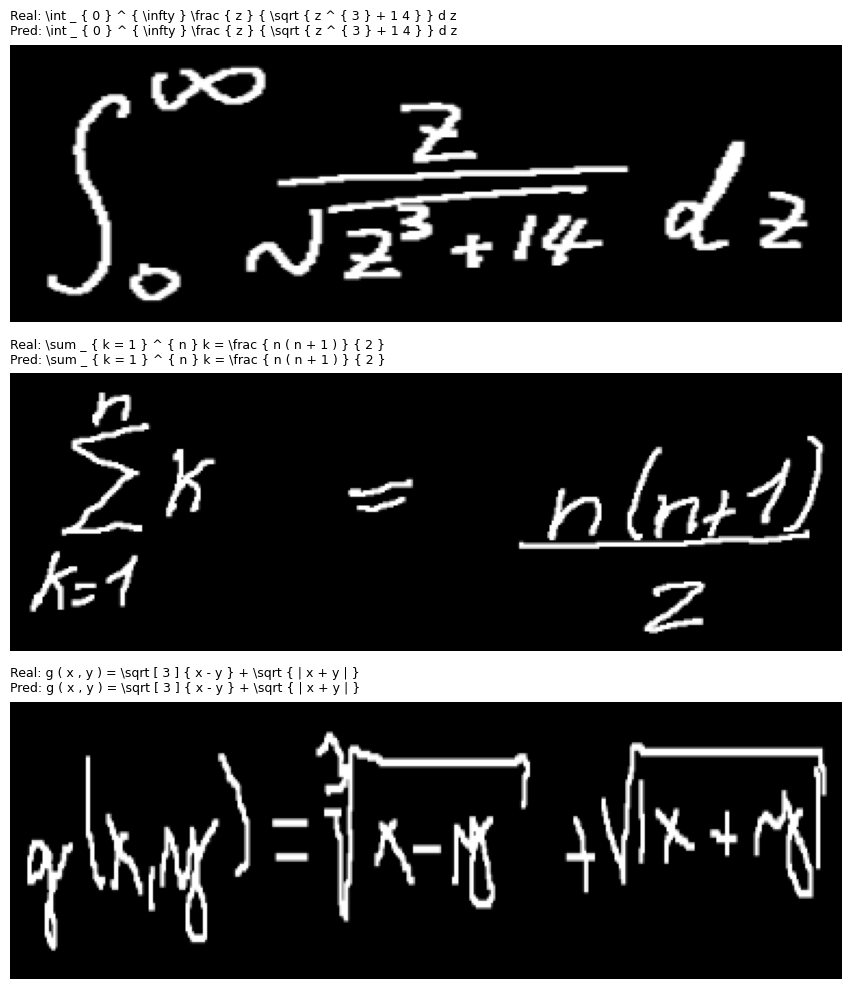

In [30]:
for (images, decoder_in), target, mask in ds_test.take(1):
    indices = random.sample(range(len(images)), 3)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    for ax, idx in zip(axes, indices):
        img   = images[idx]          # (H, W, 1)
        label = target[idx].numpy()  # (49,) — tokens reales sin BOS

        real     = decode_sequence(label, id2token)
        pred_seq = greedy_decode(model, img, vocab, id2token)
        pred     = decode_sequence(pred_seq, id2token)

        img_np = img.numpy().squeeze()
        ax.imshow(img_np, cmap="gray")
        ax.set_title(
            f"Real: {real}\nPred: {pred}",
            fontsize=9, loc="left", pad=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [31]:
test_loss, test_accuracy = model.evaluate(ds_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 91ms/step - accuracy: 0.3473 - loss: 0.0271
Test Loss: 0.027097195386886597
Test Accuracy: 0.34726518392562866


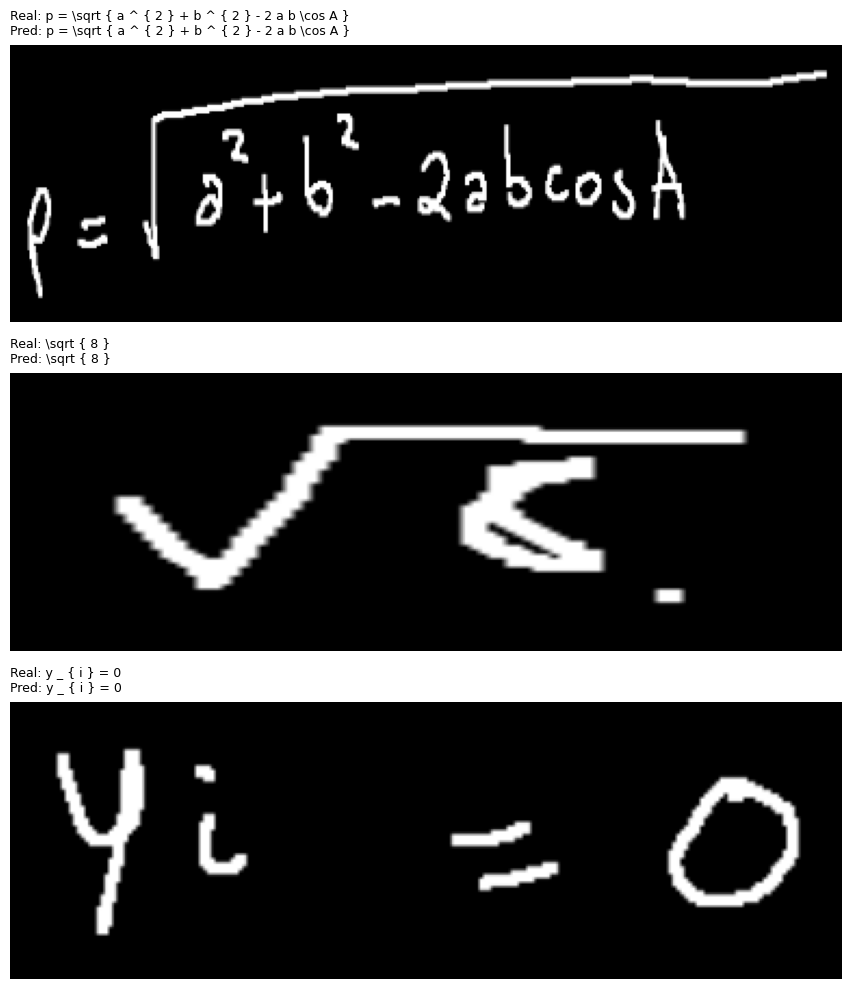

In [32]:
for (images, decoder_in), target, mask in ds_test.take(1):
    indices = random.sample(range(len(images)), 3)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    for ax, idx in zip(axes, indices):
        img   = images[idx]          # (H, W, 1)
        label = target[idx].numpy()  # (49,) — tokens reales sin BOS

        real     = decode_sequence(label, id2token)
        pred_seq = greedy_decode(model, img, vocab, id2token)
        pred     = decode_sequence(pred_seq, id2token)

        img_np = img.numpy().squeeze()
        ax.imshow(img_np, cmap="gray")
        ax.set_title(
            f"Real: {real}\nPred: {pred}",
            fontsize=9, loc="left", pad=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()